# Multiple Seeds and Ablation

Nguyễn Ngọc Hoàng Nam - B23DCCN585 | Assignment 04

In [1]:
from pathlib import Path
import os, sys, json, subprocess
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
assert (ROOT / 'src').is_dir(), 'Hãy mở notebook từ thư mục repository.'
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
from IPython.display import display, Markdown, Image
from src.data import DATASETS, load_data, data_root
print('Python:', sys.version.split()[0])
print('Dữ liệu:', data_root())

Python: 3.10.20
Dữ liệu: E:\PTHTTM\ASG_04_data


## 1. Giao thức cố định

**54 lượt chính = 3 dataset × 3 backend × 2 model × 3 seed.** Seed huấn luyện: 42, 7, 2026; split giữ seed 42. Thêm **18 ablation = 2 CIFAR × 3 can thiệp × 3 seed**, dùng PyTorch. Nhóm seed 42 cũ được tái sử dụng, không đếm lặp. Bốn pilot nằm ngoài 72 lượt.

`no_bn`: bỏ cả 4 BN; `no_skip`: chỉ bỏ phép cộng identity và giữ Conv/BN nhánh; `no_dropout`: p=0. Các can thiệp áp dụng sau khi nạp cùng trọng số khởi tạo improved. Chọn checkpoint theo validation loss, không chọn theo test. Test đã được quan sát trong quá trình phát triển nên đây là nghiên cứu khám phá.

In [2]:
protocol=json.loads((ROOT/'results/extended_protocol.json').read_text())
assert len(protocol['jobs'])==72
display(pd.DataFrame(protocol['jobs']).groupby(['backend','variant'],dropna=False).size().rename('runs'))
print('Seed huấn luyện:',protocol['seeds'],'| seed chia tập:',protocol['fixed_split_seed'])

backend     variant 
numpy       baseline     9
            improved     9
pytorch     baseline     9
            improved    27
tensorflow  baseline     9
            improved     9
Name: runs, dtype: int64

Seed huấn luyện: [42, 7, 2026] | seed chia tập: 42


## 2. Mã điều phối và định nghĩa can thiệp

Mặc định đọc kết quả đã lưu. Đặt RUN_MISSING=True để chạy các lượt còn thiếu; runner tái sử dụng các lượt hoàn chỉnh và xác nhận cấu hình. Không tự ghi đè 72 lượt. Khi cần huấn luyện lại một lượt đã có, dùng CLI với --force và sao lưu trước.

In [3]:
RUN_MISSING=False
if RUN_MISSING:
    subprocess.run([sys.executable,'run_extended.py'],cwd=ROOT,check=True)
else:
    print('Đọc kết quả 72 lượt đã huấn luyện; không chạy lại.')

Đọc kết quả 72 lượt đã huấn luyện; không chạy lại.


In [4]:
from src.torch_cnn import TorchCNN
from src.numpy_cnn import CNN
state=CNN(3,32,100,'improved',7).state()
models={}
for component in [None,'no_bn','no_skip','no_dropout']:
    model=TorchCNN(3,32,100,'improved');model.load_numpy(state);model.ablate(component)
    models[component or 'full']=sum(p.numel() for p in model.parameters())
display(pd.Series(models,name='trainable_parameters'))
assert models=={'full':76020,'no_bn':75812,'no_skip':76020,'no_dropout':76020}

full          76020
no_bn         75812
no_skip       76020
no_dropout    76020
Name: trainable_parameters, dtype: int64

## 3. Trung bình và độ lệch chuẩn

Dùng SD mẫu (ddof=1), không phải standard error và không phải khoảng tin cậy 95%. Ba seed trên cùng split chỉ đo một phần biến thiên của huấn luyện; không đánh giá biến thiên khi đổi nguồn ảnh. Không bỏ seed cho kết quả thấp.

In [5]:
runs=pd.read_csv(ROOT/'results/extended_runs.csv')
assert len(runs)==72 and runs.ablation.isna().sum()==54
summary=pd.read_csv(ROOT/'results/multiseed_summary.csv')
display(summary[['dataset','backend','variant','accuracy_mean','accuracy_std','macro_f1_mean','macro_f1_std','top5_accuracy_mean']])

,dataset,backend,variant,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,top5_accuracy_mean
0,cifar10,numpy,baseline,0.626667,0.008633,0.623889,0.009882,0.961167
1,cifar10,numpy,improved,0.652100,0.010645,0.650672,0.011146,0.968100
2,cifar10,pytorch,baseline,0.623400,0.009550,0.621018,0.010052,0.961633
3,cifar10,pytorch,improved,0.652067,0.000503,0.651388,0.001521,0.968167
4,cifar10,tensorflow,baseline,0.623800,0.010999,0.620468,0.012323,0.961300
5,cifar10,tensorflow,improved,0.655600,0.006551,0.654237,0.007102,0.969300
6,cifar100,numpy,baseline,0.282100,0.029001,0.269359,0.029815,0.578133
7,cifar100,numpy,improved,0.323200,0.001646,0.314387,0.004711,0.623367
8,cifar100,pytorch,baseline,0.290767,0.019061,0.277784,0.019821,0.585600
9,cifar100,pytorch,improved,0.324067,0.002957,0.314530,0.005535,0.624400


### MNIST

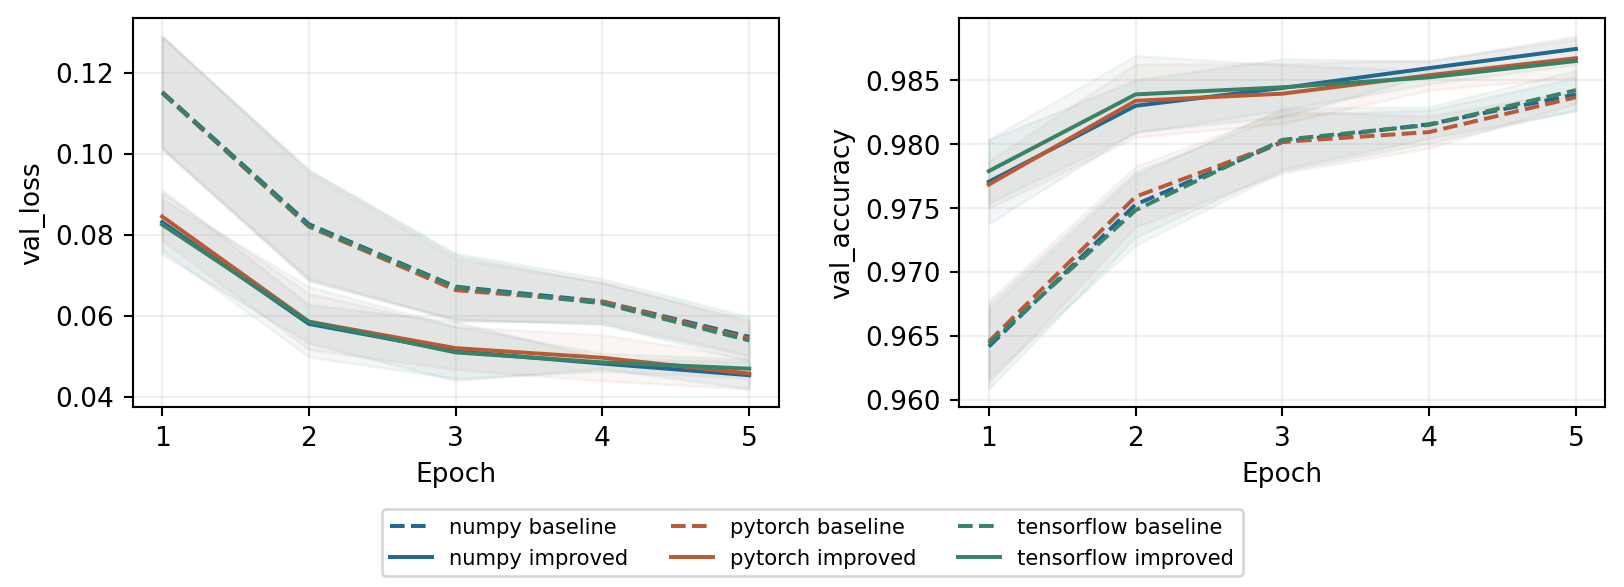

### CIFAR10

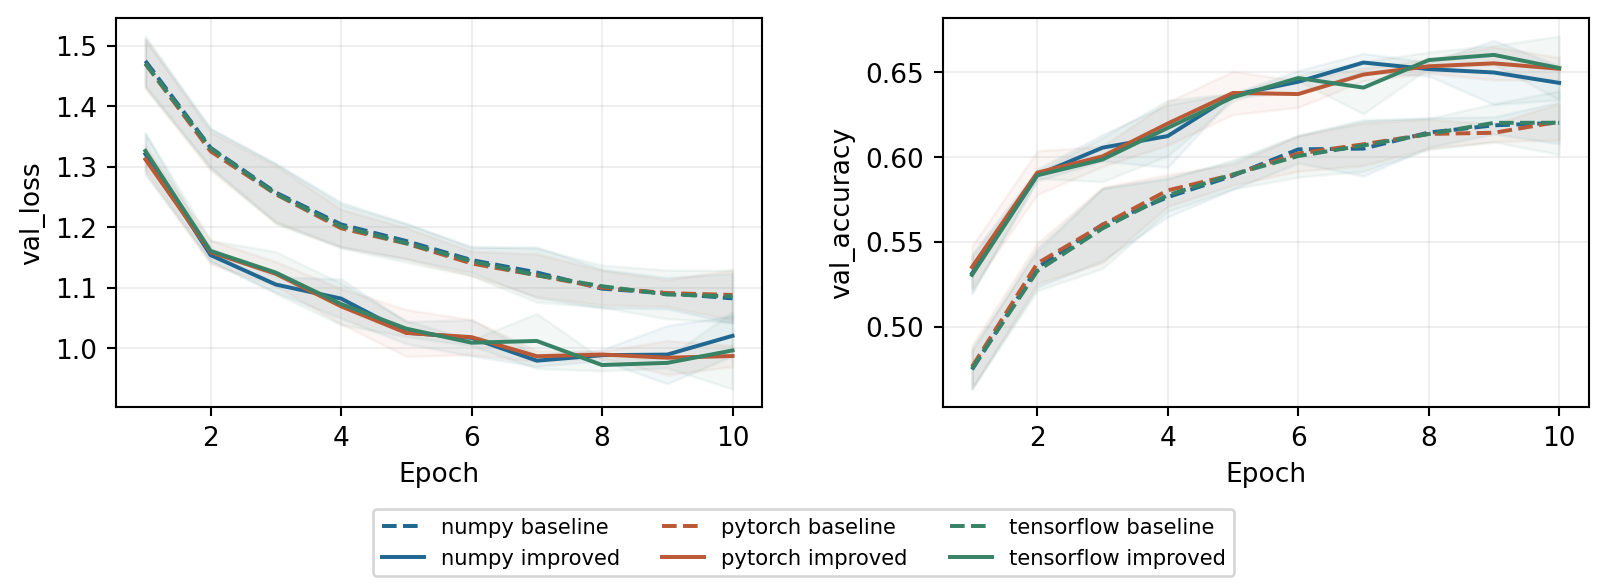

### CIFAR100

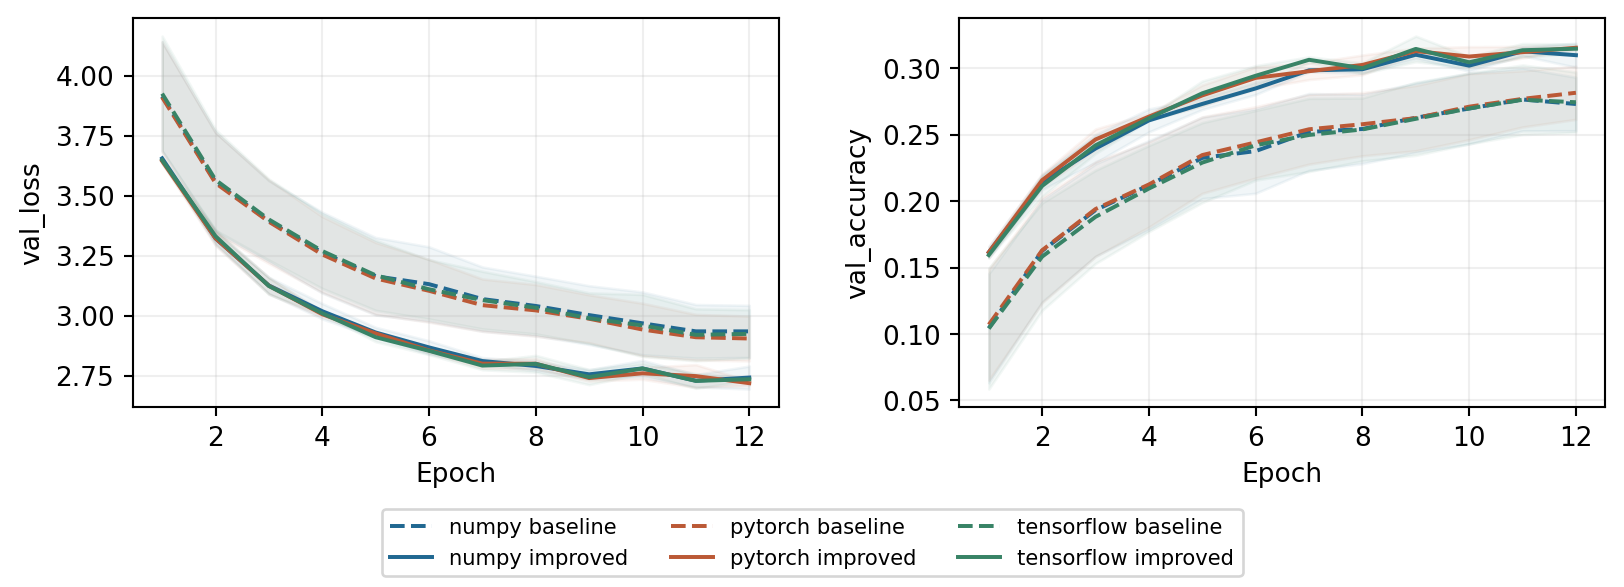

In [6]:
for name in DATASETS:
    display(Markdown('### '+name.upper()))
    display(Image(filename=str(ROOT/'figures/extended'/f'{name}_mean_curves.png')))

## 4. Chênh lệch ghép theo seed

Với mỗi dataset/backend, lấy accuracy improved trừ baseline của cùng seed rồi nhân 100 để được điểm phần trăm. Tính SD trực tiếp trên ba chênh lệch. Không dùng sự chồng lấn thanh SD làm phép kiểm định ý nghĩa thống kê.

In [7]:
gains=pd.read_csv(ROOT/'results/paired_seed_gains.csv')
display(gains)
assert len(gains)==9
print('Số cặp có improved tăng accuracy:',gains.positive_seeds.sum(),'/27')

,dataset,backend,mean_gain_pp,sd_gain_pp,positive_seeds,seed42_gain_pp,seed7_gain_pp,seed2026_gain_pp
0,mnist,numpy,0.273333,0.037859,3,0.23,0.29,0.30
1,mnist,pytorch,0.310000,0.079373,3,0.40,0.28,0.25
2,mnist,tensorflow,0.190000,0.131149,3,0.07,0.33,0.17
3,cifar10,numpy,2.543333,0.893103,3,3.28,1.55,2.80
4,cifar10,pytorch,2.866667,0.910842,3,2.23,2.46,3.91
5,cifar10,tensorflow,3.180000,1.482329,3,3.01,1.79,4.74
6,cifar100,numpy,4.110000,3.040789,3,4.19,1.03,7.11
7,cifar100,pytorch,3.330000,1.700088,3,3.31,1.64,5.04
8,cifar100,tensorflow,4.100000,2.331609,3,4.00,1.82,6.48


Số cặp có improved tăng accuracy: 27 /27


## 5. Ablation

Delta dưới đây là **biến thể trừ full improved**: âm nghĩa là tắt thành phần làm accuracy giảm. Đó là tác động có điều kiện trong kiến trúc và ngân sách hiện tại, chưa phải đóng góp độc lập áp dụng cho mọi CNN.

,dataset,ablation,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,delta_vs_full_mean_pp,delta_vs_full_std_pp,parameter_count,seed42_delta_pp,seed7_delta_pp,seed2026_delta_pp
0,cifar10,no_bn,0.621700,0.005502,0.619534,0.004665,-3.036667,0.547205,69962,-3.28,-2.41,-3.42
1,cifar10,no_dropout,0.649900,0.006321,0.646741,0.008947,-0.216667,0.582866,70170,0.33,-0.15,-0.83
2,cifar10,no_skip,0.656100,0.003759,0.656556,0.003249,0.403333,0.326548,70170,0.71,0.44,0.06
3,cifar100,no_bn,0.261567,0.018330,0.242178,0.016840,-6.250000,1.545445,75812,-7.25,-4.47,-7.03
4,cifar100,no_dropout,0.314233,0.005840,0.306205,0.008587,-0.983333,0.335460,76020,-1.37,-0.81,-0.77
5,cifar100,no_skip,0.326500,0.005027,0.317654,0.007714,0.243333,0.796639,76020,0.88,-0.65,0.50


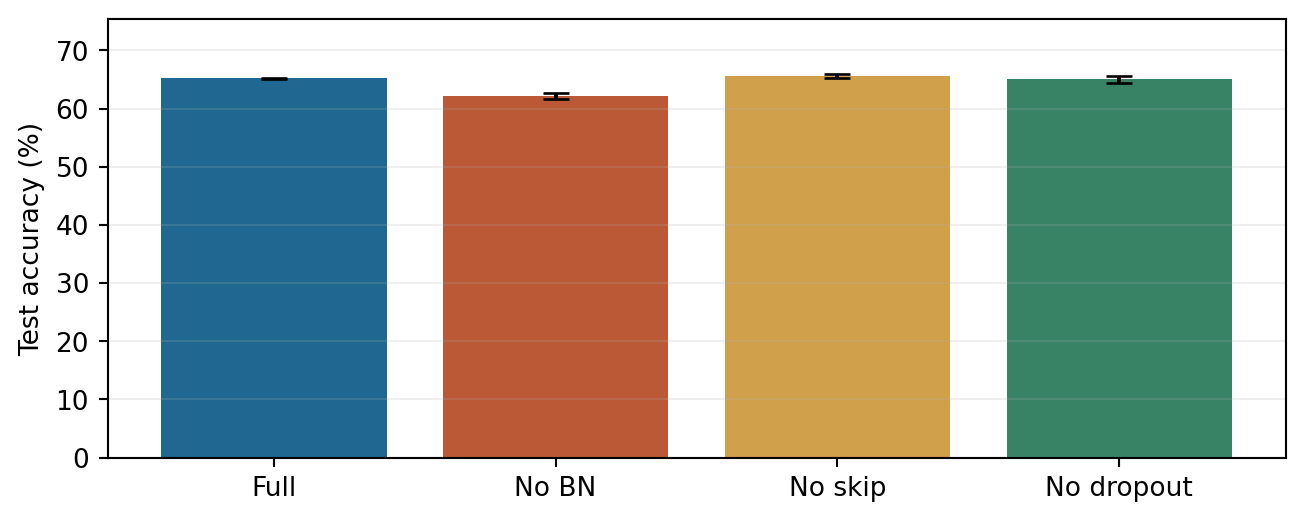

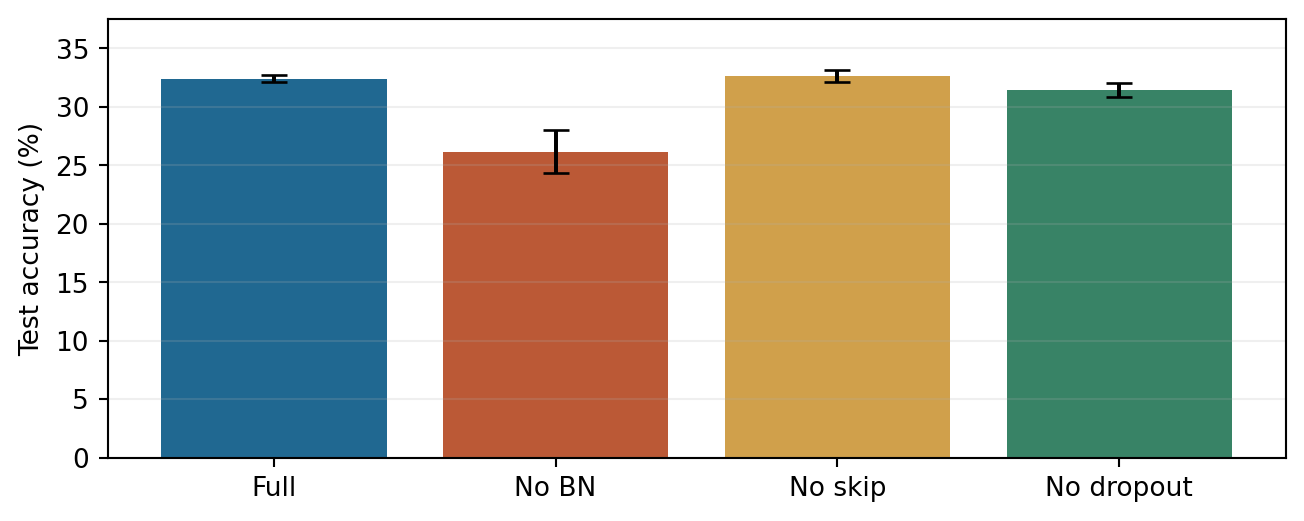

In [8]:
ablation=pd.read_csv(ROOT/'results/ablation_summary.csv')
display(ablation)
for name in ['cifar10','cifar100']:
    display(Image(filename=str(ROOT/'figures/extended'/f'{name}_ablation.png')))

## 6. Trường hợp được sửa và bị làm sai thêm

Chọn trước PyTorch seed 42 cho cả ba dataset để minh họa. Dòng trên là ảnh baseline sai nhưng improved đúng; dòng dưới ngược lại. Lấy các test_id đầu tiên theo điều kiện, không chọn thủ công ảnh đẹp. T = nhãn thật; B = baseline; I = improved.

{'dataset': 'mnist', 'reference': 'PyTorch seed 42 fixed for all datasets', 'both_correct': 9821, 'corrected': 82, 'regressed': 42, 'both_wrong': 55, 'corrected_example_ids': [18, 582, 629, 717], 'regressed_example_ids': [62, 321, 844, 882]}


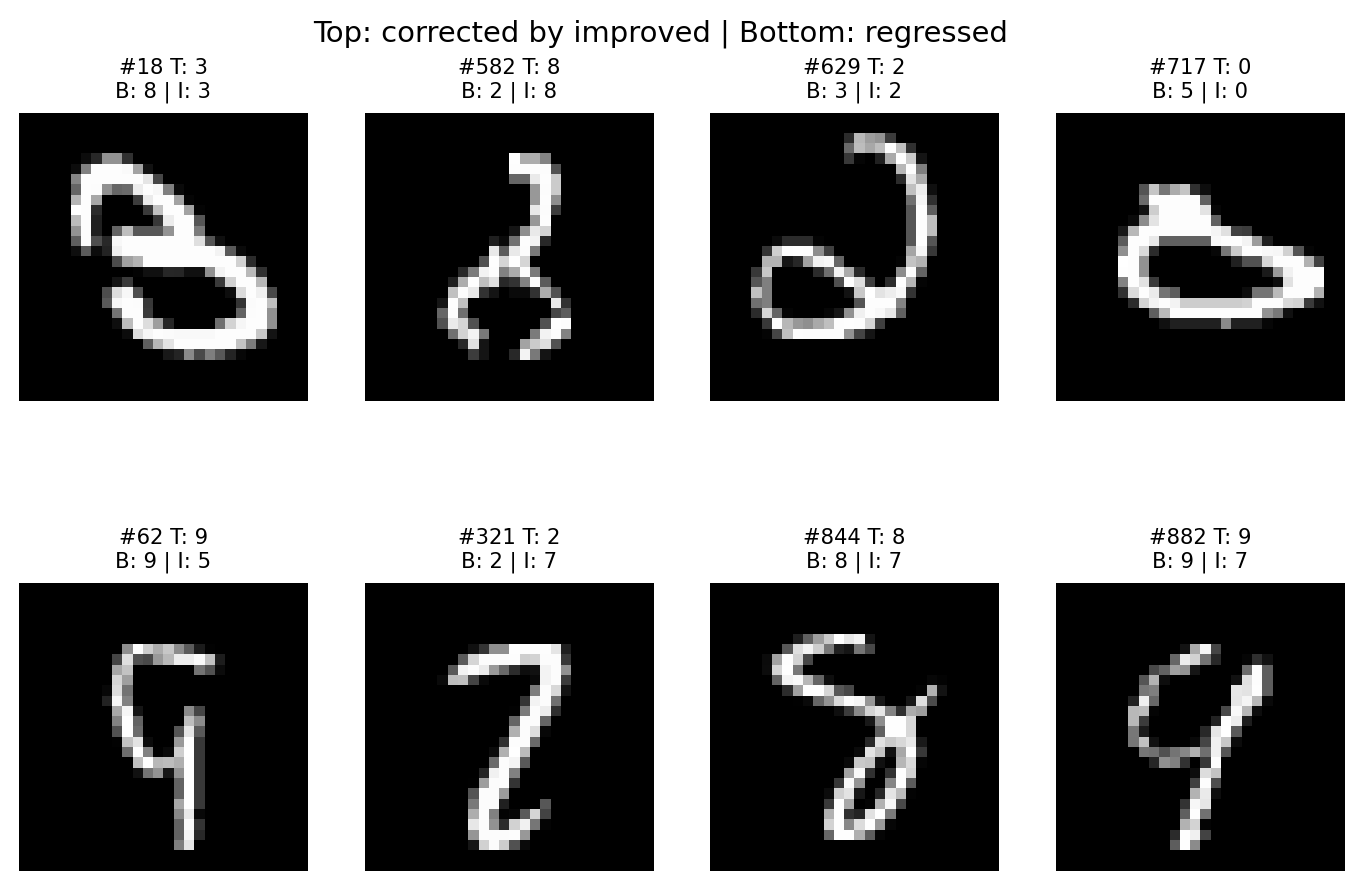

{'dataset': 'cifar10', 'reference': 'PyTorch seed 42 fixed for all datasets', 'both_correct': 5246, 'corrected': 1280, 'regressed': 1057, 'both_wrong': 2417, 'corrected_example_ids': [3, 12, 17, 22], 'regressed_example_ids': [2, 7, 10, 26]}


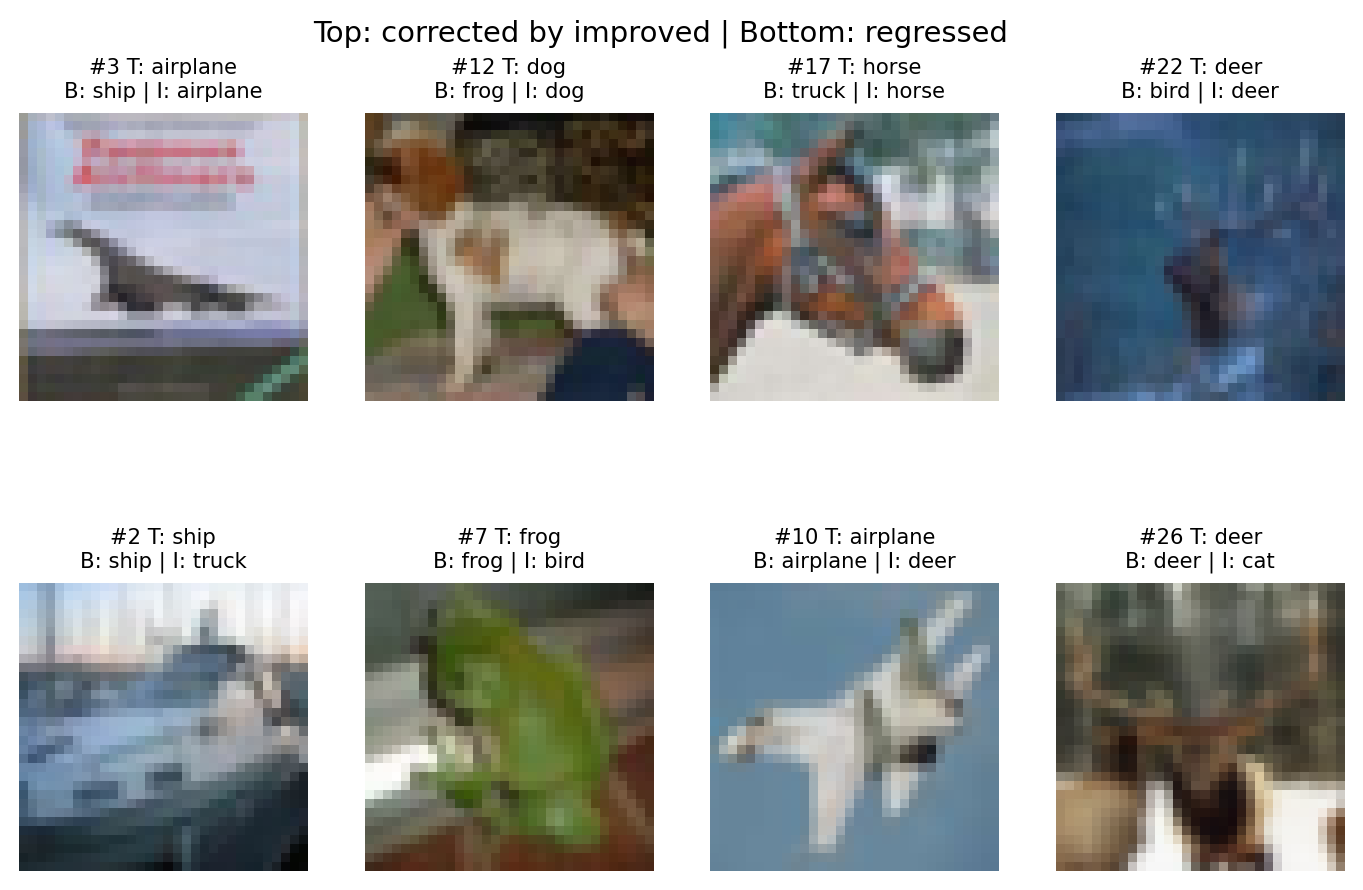

{'dataset': 'cifar100', 'reference': 'PyTorch seed 42 fixed for all datasets', 'both_correct': 2050, 'corrected': 1165, 'regressed': 834, 'both_wrong': 5951, 'corrected_example_ids': [0, 1, 8, 12], 'regressed_example_ids': [11, 20, 22, 25]}


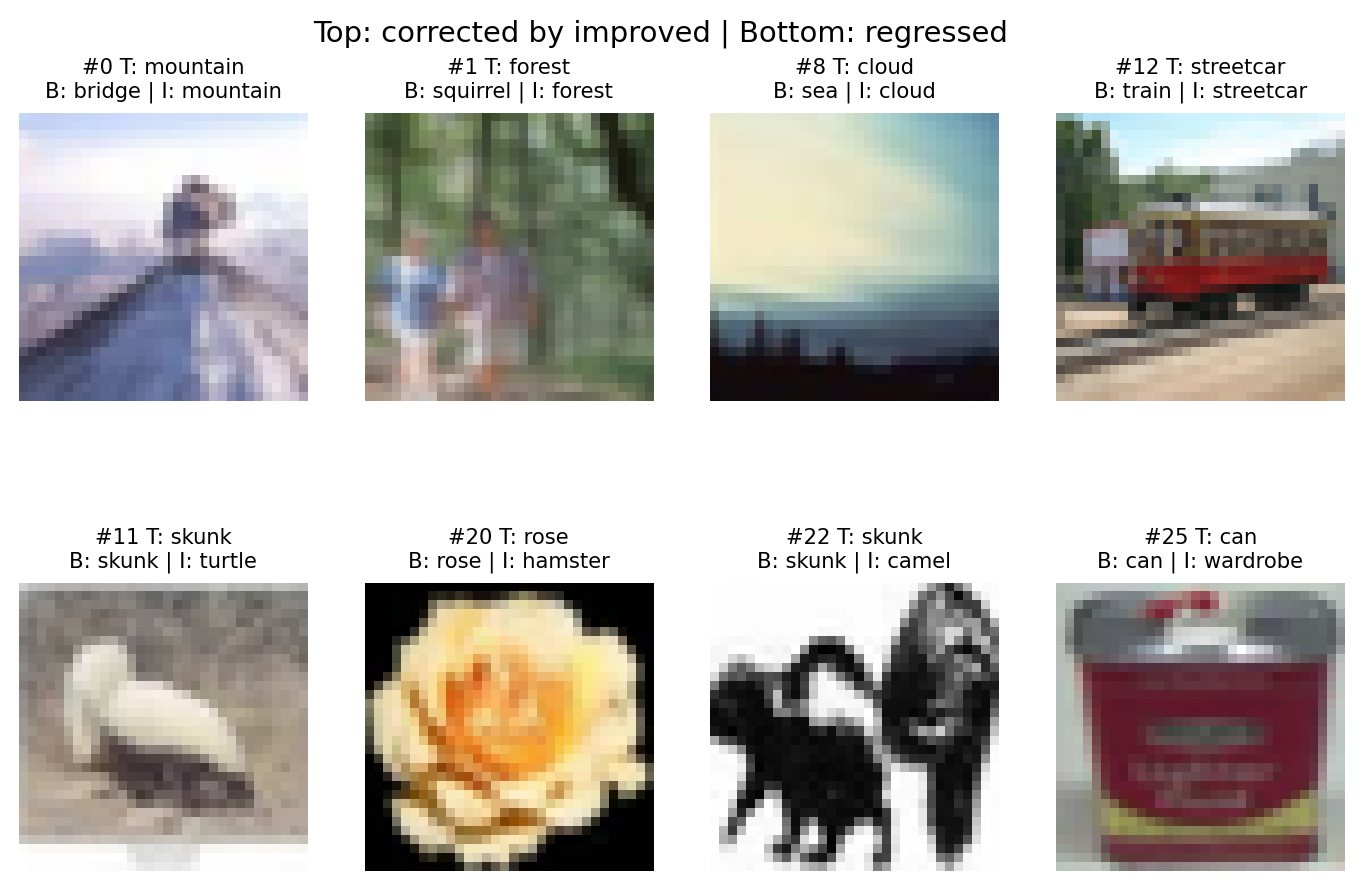

In [9]:
for name in DATASETS:
    detail=json.loads((ROOT/'results'/f'{name}_paired_errors.json').read_text())
    print(detail)
    assert sum(detail[k] for k in ['both_correct','corrected','regressed','both_wrong'])==10000
    display(Image(filename=str(ROOT/'figures/extended'/f'{name}_paired_errors.png')))

## 7. Trùng pixel và kiểm chứng đầu ra

Giữ test chính thức cho bảng chính. Phép phân tích độ nhạy CIFAR-100 loại 10 ảnh test đã xuất hiện bằng pixel trong training gốc, còn 9.990 ảnh. Nó không giải quyết near-duplicate hoặc trùng train-validation.

In [10]:
display(pd.DataFrame(json.loads((ROOT/'results/extended_duplicate_sensitivity.json').read_text())))
checks=json.loads((ROOT/'results/extended_output_verification.json').read_text())
assert len(checks)==72 and all(c['metrics_predictions_confusion_best_epoch_verified'] for c in checks)
print('Đã đối chiếu metric, dự đoán, confusion matrix và best epoch của 72 lượt.')

,backend,variant,official_mean,unseen_mean,unseen_std,excluded,retained
0,numpy,baseline,0.282100,0.282082,0.028929,10,9990
1,numpy,improved,0.323200,0.323156,0.001590,10,9990
2,pytorch,baseline,0.290767,0.290691,0.019033,10,9990
3,pytorch,improved,0.324067,0.324124,0.003048,10,9990
4,tensorflow,baseline,0.284367,0.284384,0.021993,10,9990
5,tensorflow,improved,0.325367,0.325392,0.001252,10,9990


Đã đối chiếu metric, dự đoán, confusion matrix và best epoch của 72 lượt.


## 8. Diễn giải

Trong các lượt đã chạy, improved tăng accuracy ở cả 27 cặp seed/dataset/backend. Bỏ BN làm giảm rõ trên hai bộ CIFAR. Tắt skip không làm chất lượng giảm nhất quán; CIFAR-10 còn tăng ở ba seed. Dropout có lợi rõ hơn trên CIFAR-100 trong ngân sách này. Các kết quả này không chứng minh mọi thành phần luôn cần thiết: mạng nhỏ, ba seed và chưa có mọi tổ hợp can thiệp.

Không chọn lại kiến trúc theo các kết quả test này rồi gọi cùng test là đánh giá độc lập. Chênh lệch nhỏ giữa framework chưa đủ để xếp hạng phổ quát; thời gian không phải benchmark cô lập.